In [1]:
import mujoco
import mujoco_viewer
import matplotlib.pyplot as plt
import numpy as np
import os
from lxml import etree
import mujoco.viewer
import time

In [2]:
f1 = "5bar.xml"
f2 = "5bar_modified.xml"

def swap_par(tree,element_type,element_name,attribute_name,attribute_new_value):
    element=tree.find(f'.//{element_type}[@name="{element_name}"]')

    element.set(attribute_name,attribute_new_value)




In [99]:
L_x=0.3
L1=0.2
L2=0.4
M_Mot1=0.1
M_Mot2=0.1

h=1.0
tree = etree.parse(f1)

swap_par(tree, 'body', 'base', 'pos', f"0 0 {h:.3f}")
swap_par(tree, 'geom', 'base', 'size', f"{L_x +0.1 :.3f} 0.05 0.05")

swap_par(tree, 'body', 'link1', 'pos', f"{L_x :.3f} 0.07  0")
swap_par(tree, 'geom', 'joint_shape1', 'mass', f"{M_Mot1:.3f}")
swap_par(tree, 'geom', 'link1', 'pos', f"0 0  -{L1/2:.3f}")
swap_par(tree, 'geom', 'link1', 'size', f"0.02 {L1/2:.3f}")

swap_par(tree, 'body', 'link2', 'pos', f"0 0 -{L1 +0.02 :.3f}")
swap_par(tree, 'geom', 'link2', 'pos', f"0 0 -{L2/2 +0.01 :.3f}")
swap_par(tree, 'geom', 'link2', 'size', f"0.02 {L2/2}")
swap_par(tree, 'site', 'sc1', 'pos', f"0 0 -{L2 +0.02}")

swap_par(tree, 'body', 'link3', 'pos', f"-{L_x:.3f} 0.07  0")
swap_par(tree, 'geom', 'joint_shape3', 'mass', f"{M_Mot2:.3f}")
swap_par(tree, 'geom', 'link3', 'pos', f"0 0  -{L1/2:.3f}")
swap_par(tree, 'geom', 'link3', 'size', f"0.02 {L1/2:.3f}")

swap_par(tree, 'body', 'link4', 'pos', f"0 0 -{L1 +0.02 :.3f}")
swap_par(tree, 'geom', 'link4', 'pos', f"0 0 -{L2/2 +0.01 :.3f}")
swap_par(tree, 'geom', 'link4', 'size', f"0.02 {L2/2 :.3f}")
swap_par(tree, 'site', 'sc2', 'pos', f"0 0 -{L2 +0.02 :.3f}")


# Create new xml
tree.write(f2, pretty_print=True, xml_declaration=True, encoding='UTF-8')


In [101]:
model = mujoco.MjModel.from_xml_path(f2)
data = mujoco.MjData(model)

# Joint indices (by name)
slider_id  = model.joint('slider').id
A_id       = model.joint('A').id
C_id       = model.joint('C').id
sensor_id  = model.sensor('link2_contact').id
foot=model.site('sc1').id

A_id = model.joint('A').dofadr[0]
C_id = model.joint('C').dofadr[0]

# Actuator indices
act_A = model.actuator('A').id
act_C = model.actuator('C').id
sensor_adr = model.sensor_adr[sensor_id]

# --- Jump state machine ---
CROUCH_TIME   = 0.1  # seconds to crouch
EXTEND_TIME   = 0.5 # seconds to extend (fast!)
FLIGHT_TIME   = 0.1  # wait in air before next cycle
CROUCH_ANGLE  = 1.2   # rad — how much to bend (~69 deg)
EXTEND_ANGLE  = -0.4  # rad — slight hyperextension for push-off

CROUCH_TORQUE  = 30.0
EXTEND_TORQUE  = 80.0  # much stronger for the kick


phase_start = 0.0
phase = 'crouch'  # states: crouch -> extend -> flight -> crouch ...

def get_the_height():
    return float(data.qpos[model.joint('slider').qposadr[0]])



def get_joint_angle(name):
    return float(data.qpos[model.joint(name).qposadr])

# Motor parameters (from your chosen CubeMars motor)
TAU_MAX   = 18.0   # Nm  — max stall torque
OMEGA_MAX = 27.7   # rad/s — max no-load speed

def motor_torque_limit(tau_desired, joint_name):
    """
    Clips torque based on current joint velocity.
    Uses a linear torque-speed curve (standard DC/BLDC model):
        tau_available = tau_max * (1 - |omega| / omega_max)
    """
    vadr = model.joint(joint_name).dofadr[0]
    omega = abs(float(data.qvel[vadr]))
    
    # How much torque is available at this speed?
    speed_ratio = min(omega / OMEGA_MAX, 1.0)
    tau_available = TAU_MAX * (1.0 - speed_ratio)
    
    # Clip the desired torque to what the motor can actually deliver
    return float(np.clip(tau_desired, -tau_available, tau_available))

def apply_torque(torque_A, torque_C):
    limited_A = motor_torque_limit(torque_A, 'A')
    limited_C = motor_torque_limit(torque_C, 'C')
    data.ctrl[act_A] = limited_A
    data.ctrl[act_C] = limited_C

# PD controller toward a target angle
def pd_torque(joint_name, target, kp=60.0, kd=5.0):
    adr  = model.joint(joint_name).qposadr[0]   # ← [0]
    vadr = model.joint(joint_name).dofadr[0]    # ← [0]
    q    = data.qpos[adr]
    qd   = data.qvel[vadr]
    return float(kp * (target - q) - kd * qd)





In [104]:
EE_position_x = []
EE_position_z = []
flight_time = 0.0
vz = 0.0
time_log = []
vz_log = []
flight_log = []


tau_A_log = []
tau_C_log = []

itr=1200

with mujoco.viewer.launch_passive(model, data) as viewer:
    phase_start = data.time

    for i in range(itr):
        if not viewer.is_running():
            break
        step_start = time.time()
        t = data.time
        phase_elapsed = t - phase_start
        

        position_EE = data.site_xpos[0]
        position_foot = data.site_xpos[1]
        foot_z= position_foot[2]
        
        
        


        height = position_EE[2]  # Z position of end-effector (height)
        contact=data.sensordata[sensor_adr]

        if foot_z < 0.02:
            flight_time = 0.0
            
        else:
            flight_time += model.opt.timestep
        

        vz = data.qvel[model.joint('slider').dofadr[0]]
        tau_A = data.qfrc_actuator[A_id]
        tau_C = data.qfrc_actuator[C_id]

        

        
        
        if data.time > 1.0:   # skip the first second (warmup cycle)
            time_log.append(data.time)
            vz_log.append(vz)
            flight_log.append(flight_time)
            tau_A_log.append(tau_A)
            tau_C_log.append(tau_C)
            EE_position_z.append(position_EE[2])

        
        

        
        #print(vz, flight_time)
        # ── State machine ──────────────────────────────────────────
        if phase == 'crouch':
            tA = pd_torque('A', CROUCH_ANGLE)
            tC = pd_torque('C', -CROUCH_ANGLE)   # symmetric
            apply_torque(tA, tC)
            

            if phase_elapsed > CROUCH_TIME:
                phase = 'extend'
                phase_start = t
                print(f"[{t:.2f}s] → EXTEND  height={height:.3f}")

        elif phase == 'extend':
            # Explosive extension — high-gain PD toward straight/hyper
            tA = pd_torque('A', EXTEND_ANGLE, kp=200.0, kd=8.0)
            tC = pd_torque('C', -EXTEND_ANGLE, kp=200.0, kd=8.0)
            apply_torque(tA, tC)

            if phase_elapsed > EXTEND_TIME:
                phase = 'flight'
                phase_start = t
                print(f"[{t:.2f}s] → FLIGHT  height={height:.3f}")

        elif phase == 'flight':
            # Tuck legs in air (looks nicer, prepares for landing)
            tA = pd_torque('A',  0.5, kp=20.0, kd=3.0)
            tC = pd_torque('C', -0.5, kp=20.0, kd=3.0)
            apply_torque(tA, tC)
            

            if phase_elapsed > FLIGHT_TIME:
                phase = 'crouch'
                phase_start = t
                print(f"[{t:.2f}s] → CROUCH  height={height:.3f}")
            
        
        
        # ───────────────────────────────────────────────────────────

        mujoco.mj_step(model, data)
        viewer.sync()
        time.sleep(max(0, model.opt.timestep - (time.time() - step_start)))
    max_flight = max(flight_log) if flight_log else 0.0
    max_vz   = max(vz_log)     if vz_log     else 0.0
    print(max_flight, max_vz)

[2.90s] → FLIGHT  height=0.482
[3.00s] → CROUCH  height=0.529
[3.11s] → EXTEND  height=0.601
[3.61s] → FLIGHT  height=0.482
[3.71s] → CROUCH  height=0.529
[3.81s] → EXTEND  height=0.601
[4.31s] → FLIGHT  height=0.482
[4.42s] → CROUCH  height=0.529
[4.52s] → EXTEND  height=0.601
0.23800000000000018 1.2567631779854758


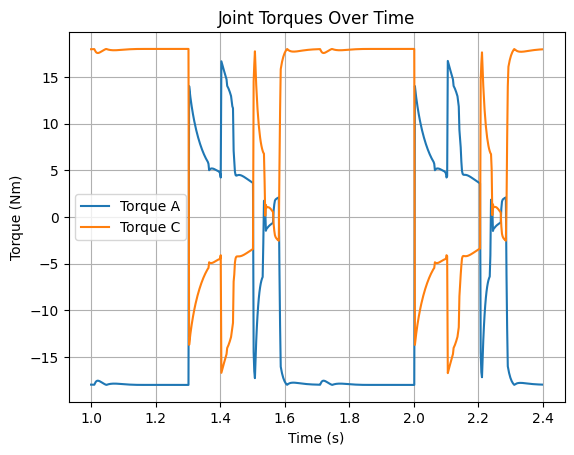

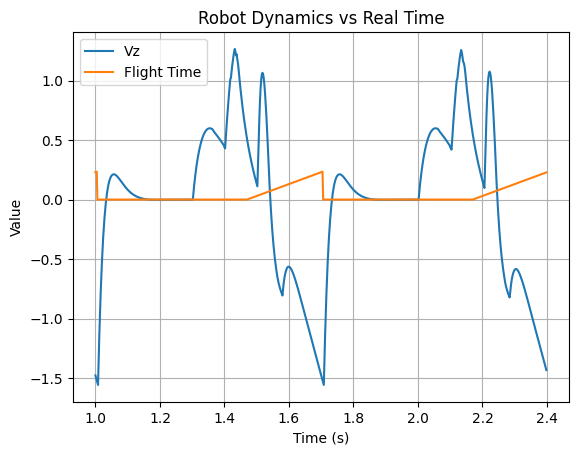

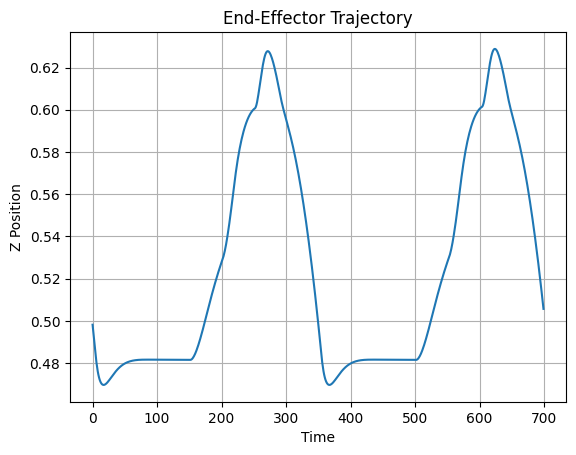

In [103]:
plt.figure()

plt.plot(time_log, tau_A_log, label="Torque A")
plt.plot(time_log, tau_C_log, label="Torque C")

plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.title("Joint Torques Over Time")
plt.legend()
plt.grid()
plt.show()

plt.figure()

plt.plot(time_log, vz_log, label="Vz")
plt.plot(time_log, flight_log, label="Flight Time")

plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("Robot Dynamics vs Real Time")
plt.legend()
plt.grid()


# Plot EE trajectory after closing the viewer
plt.figure()    
plt.plot( EE_position_z)
plt.title("End-Effector Trajectory")
plt.xlabel("Time")
plt.ylabel("Z Position")
plt.grid()
plt.show()



In [61]:
from scipy.optimize import differential_evolution, LinearConstraint, NonlinearConstraint

In [94]:




def fivebar(X,weights,motor):
    L_x=X[0]
    L1=X[1]
    L2=X[2]
    TAU_MAX   = motor["tau_max"]         # ← from selected motor
    OMEGA_MAX = motor["omega_max"]       # ← from selected motor

    h=0.5
    tree = etree.parse(f1)

    swap_par(tree, 'geom', 'base', 'size', f"{L_x +0.1} 0.05 0.05")

    swap_par(tree, 'body', 'link1', 'pos', f"{L_x :.3f} 0.07  0")
    swap_par(tree, 'geom', 'link1', 'pos', f"0 0  -{L1/2 :.3f}")
    swap_par(tree, 'geom', 'link1', 'size', f"0.02 {L1/2 :.3f}")

    swap_par(tree, 'body', 'link2', 'pos', f"0 0 -{L1 +0.02 :.3f}")
    swap_par(tree, 'geom', 'link2', 'pos', f"0 0 -{L2/2 +0.01 :.3f}")
    swap_par(tree, 'geom', 'link2', 'size', f"0.02 {L2/2 :.3f}")
    swap_par(tree, 'site', 'sc1', 'pos', f"0 0 -{L2 +0.02 :.3f}")

    swap_par(tree, 'body', 'link3', 'pos', f"-{L_x :.3f} 0.07  0")
    swap_par(tree, 'geom', 'link3', 'pos', f"0 0  -{L1/2 :.3f}")
    swap_par(tree, 'geom', 'link3', 'size', f"0.02 {L1/2 :.3f}")

    swap_par(tree, 'body', 'link4', 'pos', f"0 0 -{L1 +0.02 :.3f}")
    swap_par(tree, 'geom', 'link4', 'pos', f"0 0 -{L2/2 +0.01 :.3f}")
    swap_par(tree, 'geom', 'link4', 'size', f"0.02 {L2/2 :.3f}")
    swap_par(tree, 'site', 'sc2', 'pos', f"0 0 -{L2 +0.02 :.3f}")


    # Create new xml
    tree.write(f2, pretty_print=True, xml_declaration=True, encoding='UTF-8')

    model = mujoco.MjModel.from_xml_path(f2)
    data = mujoco.MjData(model)

    # Joint indices (by name)
    slider_id  = model.joint('slider').id
    A_id       = model.joint('A').id
    C_id       = model.joint('C').id
    sensor_id  = model.sensor('link2_contact').id
    foot=model.site('sc1').id

    A_id = model.joint('A').dofadr[0]
    C_id = model.joint('C').dofadr[0]
    weights = [20.0, 1.0]
    # Actuator indices
    act_A = model.actuator('A').id
    act_C = model.actuator('C').id
    sensor_adr = model.sensor_adr[sensor_id]

    # --- Jump state machine ---
    CROUCH_TIME   = 0.1  # seconds to crouch
    EXTEND_TIME   = 0.5 # seconds to extend (fast!)
    FLIGHT_TIME   = 0.1  # wait in air before next cycle
    CROUCH_ANGLE  = 1.2   # rad — how much to bend (~69 deg)
    EXTEND_ANGLE  = -0.4  # rad — slight hyperextension for push-off

    CROUCH_TORQUE  = 30.0
    EXTEND_TORQUE  = 80.0  # much stronger for the kick


    phase_start = 0.0
    phase = 'crouch'  # states: crouch -> extend -> flight -> crouch ...

    def get_the_height():
        return float(data.qpos[model.joint('slider').qposadr[0]])



    def get_joint_angle(name):
        return float(data.qpos[model.joint(name).qposadr])

    def apply_torque(torque_A, torque_C):
        def limit(tau, joint_name):
            vadr = model.joint(joint_name).dofadr[0]
            omega = abs(float(data.qvel[vadr]))
            tau_available = TAU_MAX * max(0.0, 1.0 - omega / OMEGA_MAX)
            return float(np.clip(tau, -tau_available, tau_available))

        data.ctrl[act_A] = limit(torque_A, 'A')
        data.ctrl[act_C] = limit(torque_C, 'C')

    # PD controller toward a target angle
    def pd_torque(joint_name, target, kp=60.0, kd=5.0):
        adr  = model.joint(joint_name).qposadr[0]   # ← [0]
        vadr = model.joint(joint_name).dofadr[0]    # ← [0]
        q    = data.qpos[adr]
        qd   = data.qvel[vadr]
        return float(kp * (target - q) - kd * qd)



    EE_position_x = []
    EE_position_z = []
    flight_time = 0.0
    vz = 0.0
    time_log = []
    vz_log = []
    flight_log = []

    time_log = []
    tau_A_log = []
    tau_C_log = []
    max_flight=[]
    max_vz=[]
    itr=1200
    with mujoco.viewer.launch_passive(model, data) as viewer:
        phase_start = data.time

        for i in range(itr):
            if not viewer.is_running():
                break
            step_start = time.time()
            t = data.time
            phase_elapsed = t - phase_start
            

            position_EE = data.site_xpos[0]
            position_foot = data.site_xpos[1]
            foot_z= position_foot[2]
            
            
            


            height = position_EE[2]  # Z position of end-effector (height)
            contact=data.sensordata[sensor_adr]

            if foot_z < 0.02:
                flight_time = 0.0
                
            else:
                flight_time += model.opt.timestep
            

            vz = data.qvel[model.joint('slider').dofadr[0]]
            tau_A = data.qfrc_actuator[A_id]
            tau_C = data.qfrc_actuator[C_id]

            if data.time > 1.0:   # skip the first second (warmup cycle)
                time_log.append(data.time)
                vz_log.append(vz)
                flight_log.append(flight_time)
                tau_A_log.append(tau_A)
                tau_C_log.append(tau_C)
                EE_position_z.append(position_EE[2])


            
            

            
            #print(vz, flight_time)
            # ── State machine ──────────────────────────────────────────
            if phase == 'crouch':
                tA = pd_torque('A', CROUCH_ANGLE)
                tC = pd_torque('C', -CROUCH_ANGLE)   # symmetric
                apply_torque(tA, tC)
                

                if phase_elapsed > CROUCH_TIME:
                    phase = 'extend'
                    phase_start = t
                    print(f"[{t:.2f}s] → EXTEND  height={height:.3f}")

            elif phase == 'extend':
                # Explosive extension — high-gain PD toward straight/hyper
                tA = pd_torque('A', EXTEND_ANGLE, kp=200.0, kd=8.0)
                tC = pd_torque('C', -EXTEND_ANGLE, kp=200.0, kd=8.0)
                apply_torque(tA, tC)

                if phase_elapsed > EXTEND_TIME:
                    phase = 'flight'
                    phase_start = t
                    print(f"[{t:.2f}s] → FLIGHT  height={height:.3f}")

            elif phase == 'flight':
                # Tuck legs in air (looks nicer, prepares for landing)
                tA = pd_torque('A',  0.5, kp=20.0, kd=3.0)
                tC = pd_torque('C', -0.5, kp=20.0, kd=3.0)
                apply_torque(tA, tC)
                

                if phase_elapsed > FLIGHT_TIME:
                    phase = 'crouch'
                    phase_start = t
                    print(f"[{t:.2f}s] → CROUCH  height={height:.3f}")
                
            
            
            # ───────────────────────────────────────────────────────────

            mujoco.mj_step(model, data)
            viewer.sync()
            time.sleep(max(0, model.opt.timestep - (time.time() - step_start)))

        max_flight = max(flight_log) if flight_log else 0.0
        max_vz   = max(vz_log)     if vz_log     else 0.0

            # If robot never left the ground, return worst possible reward
            #if max_flight < 0.5:   # never got 5cm of flight time... wait
                #return 0.0          # ← punish motors too weak to jump
    
   
    return -1 * (weights[0] * max_flight + weights[1] * max_vz)




In [ ]:

# RPM to rad/s converter
def rpm_to_rads(rpm):
    return rpm * 2 * np.pi / 60

MOTOR_CATALOGUE = [
    # AK Series
    {"name": "AK10-9 V3.0",   "tau_max": 18.0, "omega_max": rpm_to_rads(235),  "price": 698.9},
    {"name": "AK10-9 V2.0",   "tau_max": 18.0, "omega_max": rpm_to_rads(228),  "price": 698.9},  # 48V speed
    {"name": "AK80-9 V3.0",   "tau_max":  9.0, "omega_max": rpm_to_rads(390),  "price": 479.9},
    {"name": "AK80-8",        "tau_max": 10.0, "omega_max": rpm_to_rads(243),  "price": 469.9},
    {"name": "AK80-6",        "tau_max":  6.0, "omega_max": rpm_to_rads(603),  "price": 469.9},
    {"name": "AK80-64",       "tau_max": 48.0, "omega_max": rpm_to_rads(48),   "price": 889.9},  # 48V speed
    {"name": "AK70-10",       "tau_max":  8.3, "omega_max": rpm_to_rads(310),  "price": 398.9},  # 48V speed
    {"name": "AK70-9",        "tau_max":  8.5, "omega_max": rpm_to_rads(260),  "price": 398.9},
    {"name": "AK60-6 V3.0",   "tau_max":  3.0, "omega_max": rpm_to_rads(490),  "price": 229.9},  # 48V speed
    {"name": "AK60-39 V3.0",  "tau_max": 24.0, "omega_max": rpm_to_rads(70),   "price": 448.9},
    {"name": "AK60-6 V1.1 KV140", "tau_max": 3.0, "omega_max": rpm_to_rads(420), "price": 298.9},
    {"name": "AK60-6 V1.1 KV80",  "tau_max": 3.0, "omega_max": rpm_to_rads(233), "price": 298.9},
    {"name": "AK45-36",       "tau_max":  8.0, "omega_max": rpm_to_rads(40),   "price": 149.9},
    {"name": "AK45-10",       "tau_max":  2.5, "omega_max": rpm_to_rads(150),  "price": 119.9},
    {"name": "AK40-10",       "tau_max":  1.3, "omega_max": rpm_to_rads(370),  "price":  99.9},
    # AKA Series
    {"name": "AKA10-9",       "tau_max": 18.0, "omega_max": rpm_to_rads(109),  "price": 798.9},
    {"name": "AKA60-6",       "tau_max":  3.0, "omega_max": rpm_to_rads(400),  "price": 298.9},  # 48V speed
    # AKH Series
    {"name": "AKH70-16",      "tau_max": 26.0, "omega_max": rpm_to_rads(90),   "price": 598.9},
    {"name": "AKH70-48",      "tau_max": 74.0, "omega_max": rpm_to_rads(28),   "price": 698.9},
]

# ── Wrapper for differential_evolution ────────────────────────────
def fivebar_with_motor(params, weights):
    L_x = params[0]
    L1  = params[1]
    L2  = params[2]
    motor_idx = int(round(np.clip(params[3], 0, len(MOTOR_CATALOGUE) - 1)))
    motor = MOTOR_CATALOGUE[motor_idx]

    print(f"  Testing motor: {motor['name']}, L_x={L_x:.3f}, L1={L1:.3f}, L2={L2:.3f}")
    return fivebar([L_x, L1, L2], weights, motor)   # ← pass motor through

# ── Optimization ───────────────────────────────────────────────────
weights = [10.0, 10.0]

def motor_torque(p):
    idx = int(round(np.clip(p[3], 0, len(MOTOR_CATALOGUE)-1)))
    return MOTOR_CATALOGUE[idx]["tau_max"]

constraints = [
    LinearConstraint([-1, 1, 1, 0], 0, np.inf),  # L1+L2 >= L_x
    NonlinearConstraint(motor_torque, 8.0, np.inf),  # tau >= 8 Nm
]

bnds = [
    (0.160, 0.4),                          # L_x
    (0.1,   0.4),                          # L1
    (0.1,   0.4),                          # L2
    (0, len(MOTOR_CATALOGUE) - 1),         # motor index ← discrete
]

result = differential_evolution(
    fivebar_with_motor,
    bounds=bnds,
    args=(weights,),
    seed=42,
    maxiter=10,
    popsize=12,
    tol=1e-3,
    integrality=[False, False, False, True],
    constraints=constraints,
)

'''L_x_init=0.3
L1_init=0.3
L2_init=0.4
weights = [20.0, 1.0]
X_init=np.array([L_x_init, L1_init, L2_init])

bnds = [(0.160, 0.4), (0.1, 0.4), (0.1, 0.4)]  # bounds for L_x, L1, L2
opts = {'fatol': 1e-7, 'maxiter': 100}
result = minimize(
    fivebar, 
    X_init, 
    args=(weights,),  # <--- Inserted here
    method='SLSQP', 
    options=opts ,
    bounds=bnds)'''



  Testing motor: AKH70-48, L_x=0.216, L1=0.233, L2=0.354
[0.10s] → EXTEND  height=0.936
[0.60s] → FLIGHT  height=0.503
[0.70s] → CROUCH  height=0.558
[0.80s] → EXTEND  height=0.597
[1.30s] → FLIGHT  height=0.503
[1.40s] → CROUCH  height=0.558
[1.50s] → EXTEND  height=0.597
[2.00s] → FLIGHT  height=0.503
[2.10s] → CROUCH  height=0.559
[2.20s] → EXTEND  height=0.597
  Testing motor: AK80-64, L_x=0.285, L1=0.176, L2=0.312
[0.10s] → EXTEND  height=0.924
[0.60s] → FLIGHT  height=0.347
[0.70s] → CROUCH  height=0.403
[0.80s] → EXTEND  height=0.461
[1.30s] → FLIGHT  height=0.347
[1.40s] → CROUCH  height=0.402
[1.50s] → EXTEND  height=0.460
[2.00s] → FLIGHT  height=0.347
[2.10s] → CROUCH  height=0.403
[2.20s] → EXTEND  height=0.461
  Testing motor: AK10-9 V2.0, L_x=0.188, L1=0.142, L2=0.367
[0.10s] → EXTEND  height=0.922
[0.60s] → FLIGHT  height=0.461
[0.70s] → CROUCH  height=0.508
[0.80s] → EXTEND  height=0.534
[1.30s] → FLIGHT  height=0.461
[1.40s] → CROUCH  height=0.508
[1.50s] → EXTEND  hei

C:\Users\Sky Code\AppData\Roaming\Python\Python312\site-packages\scipy\optimize\_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
C:\Users\Sky Code\AppData\Roaming\Python\Python312\site-packages\scipy\optimize\_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


  Testing motor: AK10-9 V2.0, L_x=0.266, L1=0.248, L2=0.374
[0.10s] → EXTEND  height=0.908
[0.60s] → FLIGHT  height=0.518
[0.70s] → CROUCH  height=0.562
[0.80s] → EXTEND  height=0.633
[1.30s] → FLIGHT  height=0.518
[1.40s] → CROUCH  height=0.562
[1.50s] → EXTEND  height=0.633
[2.00s] → FLIGHT  height=0.518
[2.10s] → CROUCH  height=0.563
[2.20s] → EXTEND  height=0.633
  Testing motor: AK10-9 V2.0, L_x=0.266, L1=0.248, L2=0.374
[0.10s] → EXTEND  height=0.908
[0.60s] → FLIGHT  height=0.518
[0.70s] → CROUCH  height=0.562
[0.80s] → EXTEND  height=0.633
[1.30s] → FLIGHT  height=0.518
[1.40s] → CROUCH  height=0.562
[1.50s] → EXTEND  height=0.633
[2.00s] → FLIGHT  height=0.518
[2.10s] → CROUCH  height=0.563
[2.20s] → EXTEND  height=0.633
  Testing motor: AK10-9 V2.0, L_x=0.266, L1=0.248, L2=0.374
[0.10s] → EXTEND  height=0.908
[0.60s] → FLIGHT  height=0.518
[0.70s] → CROUCH  height=0.562
[0.80s] → EXTEND  height=0.633
[1.30s] → FLIGHT  height=0.518
[1.40s] → CROUCH  height=0.562
[1.50s] → EXTE

"L_x_init=0.3\nL1_init=0.3\nL2_init=0.4\nweights = [20.0, 1.0]\nX_init=np.array([L_x_init, L1_init, L2_init])\n\nbnds = [(0.160, 0.4), (0.1, 0.4), (0.1, 0.4)]  # bounds for L_x, L1, L2\nopts = {'fatol': 1e-7, 'maxiter': 100}\nresult = minimize(\n    fivebar, \n    X_init, \n    args=(weights,),  # <--- Inserted here\n    method='SLSQP', \n    options=opts ,\n    bounds=bnds)"

In [96]:
result



             message: Maximum number of iterations has been exceeded.
             success: False
                 fun: -8.511645108338897
                   x: [ 3.612e-01  1.496e-01  2.953e-01  1.000e+00]
                 nit: 10
                nfev: 613
          population: [[ 3.612e-01  1.496e-01  2.953e-01  1.000e+00]
                       [ 2.840e-01  2.333e-01  2.415e-01  1.000e+00]
                       ...
                       [ 3.582e-01  1.270e-01  2.905e-01  0.000e+00]
                       [ 2.563e-01  1.707e-01  1.739e-01  1.000e+00]]
 population_energies: [-8.512e+00 -7.119e+00 ... -8.386e+00 -7.454e+00]
              constr: [array([ 0.000e+00]), array([ 0.000e+00])]
    constr_violation: 0.0
               maxcv: 0.0

In [106]:
X=result.x
L_x=X[0]
L1=X[1]
L2=X[2]

h=1
tree = etree.parse(f1)
motor=MOTOR_CATALOGUE[int(round(np.clip(result.x[3], 0, len(MOTOR_CATALOGUE) - 1)))]

swap_par(tree, 'geom', 'base', 'size', f"{L_x+0.1 :.3f} 0.05 0.05")

swap_par(tree, 'body', 'link1', 'pos', f"{L_x :.3f} 0.07  0")
swap_par(tree, 'geom', 'link1', 'pos', f"0 0  -{L1/2 :.3f}")
swap_par(tree, 'geom', 'link1', 'size', f"0.02 {L1/2 :.3f}")

swap_par(tree, 'body', 'link2', 'pos', f"0 0 -{L1 +0.02 :.3f}")
swap_par(tree, 'geom', 'link2', 'pos', f"0 0 -{L2/2 +0.01 :.3f}")
swap_par(tree, 'geom', 'link2', 'size', f"0.02 {L2/2 :.3f}")
swap_par(tree, 'site', 'sc1', 'pos', f"0 0 -{L2 +0.02 :.3f}")

swap_par(tree, 'body', 'link3', 'pos', f"-{L_x :.3f} 0.07  0")
swap_par(tree, 'geom', 'link3', 'pos', f"0 0  -{L1/2 :.3f}")
swap_par(tree, 'geom', 'link3', 'size', f"0.02 {L1/2 :.3f}")

swap_par(tree, 'body', 'link4', 'pos', f"0 0 -{L1 +0.02 :.3f}")
swap_par(tree, 'geom', 'link4', 'pos', f"0 0 -{L2/2 +0.01 :.3f}")
swap_par(tree, 'geom', 'link4', 'size', f"0.02 {L2/2 :.3f}")
swap_par(tree, 'site', 'sc2', 'pos', f"0 0 -{L2 +0.02 :.3f}")


# Create new xml
tree.write(f2, pretty_print=True, xml_declaration=True, encoding='UTF-8')

model = mujoco.MjModel.from_xml_path(f2)
data = mujoco.MjData(model)

# Joint indices (by name)
slider_id  = model.joint('slider').id
A_id       = model.joint('A').id
C_id       = model.joint('C').id
sensor_id  = model.sensor('link2_contact').id
foot=model.site('sc1').id

A_id = model.joint('A').dofadr[0]
C_id = model.joint('C').dofadr[0]
weights = [20.0, 1.0]
# Actuator indices
act_A = model.actuator('A').id
act_C = model.actuator('C').id
sensor_adr = model.sensor_adr[sensor_id]
TAU_MAX   = motor["tau_max"]         # ← from selected motor
OMEGA_MAX = motor["omega_max"]       # ← from selected motor

# --- Jump state machine ---
CROUCH_TIME   = 0.1  # seconds to crouch
EXTEND_TIME   = 0.5 # seconds to extend (fast!)
FLIGHT_TIME   = 0.1  # wait in air before next cycle
CROUCH_ANGLE  = 1.2   # rad — how much to bend (~69 deg)
EXTEND_ANGLE  = -0.4  # rad — slight hyperextension for push-off

CROUCH_TORQUE  = 30.0
EXTEND_TORQUE  = 80.0  # much stronger for the kick


phase_start = 0.0
phase = 'crouch'  # states: crouch -> extend -> flight -> crouch ...

def get_the_height():
    return float(data.qpos[model.joint('slider').qposadr[0]])



def get_joint_angle(name):
    return float(data.qpos[model.joint(name).qposadr])

def apply_torque(torque_A, torque_C):
    def limit(tau, joint_name):
        vadr = model.joint(joint_name).dofadr[0]
        omega = abs(float(data.qvel[vadr]))
        tau_available = TAU_MAX * max(0.0, 1.0 - omega / OMEGA_MAX)
        return float(np.clip(tau, -tau_available, tau_available))

    data.ctrl[act_A] = limit(torque_A, 'A')
    data.ctrl[act_C] = limit(torque_C, 'C')

# PD controller toward a target angle
def pd_torque(joint_name, target, kp=60.0, kd=5.0):
    adr  = model.joint(joint_name).qposadr[0]   # ← [0]
    vadr = model.joint(joint_name).dofadr[0]    # ← [0]
    q    = data.qpos[adr]
    qd   = data.qvel[vadr]
    return float(kp * (target - q) - kd * qd)



EE_position_x = []
EE_position_z = []
flight_time = 0.0
vz = 0.0
time_log = []
vz_log = []
flight_log = []

time_log = []
tau_A_log = []
tau_C_log = []
itr=10000
with mujoco.viewer.launch_passive(model, data) as viewer:
    phase_start = data.time

    for i in range(itr):
        if not viewer.is_running():
            break
        step_start = time.time()
        t = data.time
        phase_elapsed = t - phase_start
        

        position_EE = data.site_xpos[0]
        position_foot = data.site_xpos[1]
        foot_z= position_foot[2]
        
        
        


        height = position_EE[2]  # Z position of end-effector (height)
        contact=data.sensordata[sensor_adr]

        if foot_z < 0.02:
            flight_time = 0.0
            
        else:
            flight_time += model.opt.timestep
        

        vz = data.qvel[model.joint('slider').dofadr[0]]
        tau_A = data.qfrc_actuator[A_id]
        tau_C = data.qfrc_actuator[C_id]

        if data.time > 1.0:   # skip the first second (warmup cycle)
            time_log.append(data.time)
            vz_log.append(vz)
            flight_log.append(flight_time)
            tau_A_log.append(tau_A)
            tau_C_log.append(tau_C)
            EE_position_z.append(position_EE[2])
        


        
        

        
        #print(vz, flight_time)
        # ── State machine ──────────────────────────────────────────
        if phase == 'crouch':
            tA = pd_torque('A', CROUCH_ANGLE)
            tC = pd_torque('C', -CROUCH_ANGLE)   # symmetric
            apply_torque(tA, tC)
            

            if phase_elapsed > CROUCH_TIME:
                phase = 'extend'
                phase_start = t
                print(f"[{t:.2f}s] → EXTEND  height={height:.3f}")

        elif phase == 'extend':
            # Explosive extension — high-gain PD toward straight/hyper
            tA = pd_torque('A', EXTEND_ANGLE, kp=200.0, kd=8.0)
            tC = pd_torque('C', -EXTEND_ANGLE, kp=200.0, kd=8.0)
            apply_torque(tA, tC)

            if phase_elapsed > EXTEND_TIME:
                phase = 'flight'
                phase_start = t
                print(f"[{t:.2f}s] → FLIGHT  height={height:.3f}")

        elif phase == 'flight':
            # Tuck legs in air (looks nicer, prepares for landing)
            tA = pd_torque('A',  0.5, kp=20.0, kd=3.0)
            tC = pd_torque('C', -0.5, kp=20.0, kd=3.0)
            apply_torque(tA, tC)
            

            if phase_elapsed > FLIGHT_TIME:
                phase = 'crouch'
                phase_start = t
                print(f"[{t:.2f}s] → CROUCH  height={height:.3f}")
            
        
        
        # ───────────────────────────────────────────────────────────

        mujoco.mj_step(model, data)
        viewer.sync()
        time.sleep(max(0, model.opt.timestep - (time.time() - step_start)))
    max_flight = max(flight_log) if flight_log else 0.0
    max_vz   = max(vz_log)     if vz_log     else 0.0
    print(max_flight, max_vz)




[0.10s] → EXTEND  height=0.905
[0.60s] → FLIGHT  height=0.236
[0.70s] → CROUCH  height=0.250
[0.80s] → EXTEND  height=0.352
[1.30s] → FLIGHT  height=0.238
[1.40s] → CROUCH  height=0.250
[1.50s] → EXTEND  height=0.351
[2.00s] → FLIGHT  height=0.238
[2.10s] → CROUCH  height=0.250
[2.20s] → EXTEND  height=0.354
[2.71s] → FLIGHT  height=0.238
[2.81s] → CROUCH  height=0.250
[2.91s] → EXTEND  height=0.354
[3.41s] → FLIGHT  height=0.238
[3.51s] → CROUCH  height=0.250
[3.62s] → EXTEND  height=0.354
0.34000000000000025 1.7116451083388924


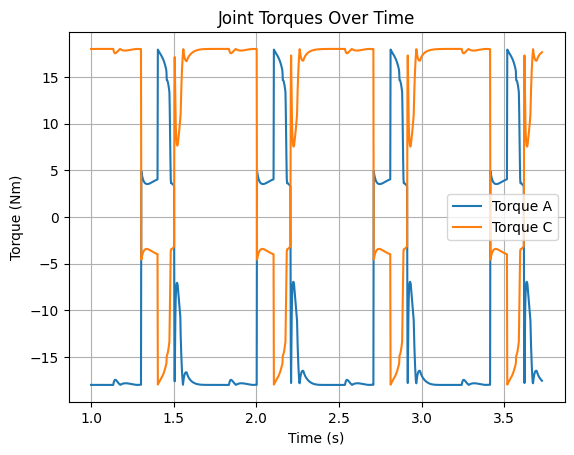

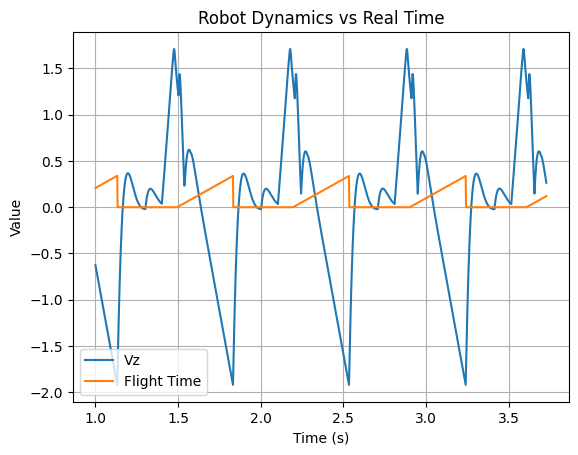

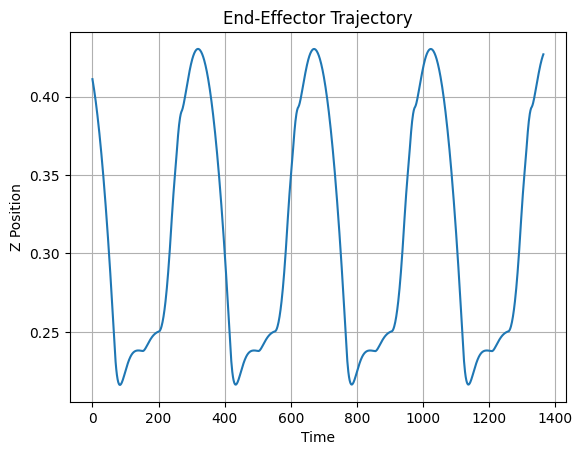

In [107]:
plt.figure()

plt.plot(time_log, tau_A_log, label="Torque A")
plt.plot(time_log, tau_C_log, label="Torque C")

plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.title("Joint Torques Over Time")
plt.legend()
plt.grid()
plt.show()

plt.figure()

plt.plot(time_log, vz_log, label="Vz")
plt.plot(time_log, flight_log, label="Flight Time")

plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("Robot Dynamics vs Real Time")
plt.legend()
plt.grid()


# Plot EE trajectory after closing the viewer
plt.figure()    
plt.plot( EE_position_z)
plt.title("End-Effector Trajectory")
plt.xlabel("Time")
plt.ylabel("Z Position")
plt.grid()
plt.show()

